<a href="https://colab.research.google.com/github/Solaidiaghe1/BlueBridge/blob/main/woonsocket_report_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Woonsocket load generators: closed-loop vs open-loop (constant, Poisson)

**What this report shows.** I built three request generators for a small TCP request/response server and swept each across three server workloads (`Immediate`, `Const:50`, `Payload`). Every run lasts a fixed window (derived below, 10 s) and records per-request latency; this notebook analyses the merged results (`merged_results.csv`, one row per run).

**Headline findings** (all numbers are computed in the cells below):

1. **Attempted ≠ offered ≠ achieved.** Open-loop generators offer ≈98.5 % of the attempted rate until the sender hits a ceiling of ≈110–146k req/s; above that, offered load stops tracking attempted load. Past the server's capacity, *achieved* throughput drops to ≈40 % of *offered*.
2. **Open loop exposes saturation; closed loop hides it.** Closed-loop p99 never exceeds ≈1.1 ms, because the generator slows down when the server does (Little's law). Open-loop latency jumps from tens of microseconds to **seconds** once offered load passes capacity.
3. **Burstiness costs latency at equal load.** At matched offered load below saturation, Poisson arrivals have a p95 about 1.1–3.1× that of constant-rate arrivals (Immediate and Const:50).
4. **Sampling detail matters.** My Poisson sampler truncates inter-arrival times to whole microseconds, which biases offered load upward by up to ≈5 % at an 8 µs mean. The effect is predictable and I quantify it in §3.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

df = pd.read_csv('merged_results.csv')

# Run length is not a column; recover it from sent / offered_rps (offered = sent / runtime).
RUNTIME = int(round((df.sent / df.offered_rps).median()))
assert ((df.sent / df.offered_rps - RUNTIME).abs() < 0.05).all()

# `value` means different things per strategy: #threads for closed-loop, inter-arrival interval (µs) for open-loop.
df['threads']     = np.where(df.strategy == 'closed-loop', df.value, np.nan)
df['interval_us'] = np.where(df.strategy == 'closed-loop', np.nan, df.value)
df['attempted_rps'] = 1e6 / df.interval_us                    # open-loop only: the *intended* rate
for p in ('p50', 'p95', 'p99'): df[p + '_ms'] = df[p + '_us'] / 1000
df['saturated'] = df.completion_pct < 99                      # run did not complete (nearly) everything it sent
df['backlog']   = df.sent - df.completed_counts               # requests still outstanding when the run ended

STRATS = ['closed-loop', 'open-loop-constant', 'open-loop-poisson']
LBL = {'closed-loop': 'Closed-loop', 'open-loop-constant': 'Open-loop constant', 'open-loop-poisson': 'Open-loop Poisson'}
COL = {'closed-loop': 'tab:green', 'open-loop-constant': 'tab:blue', 'open-loop-poisson': 'tab:red'}
WL  = ['Immediate', 'Const:50', 'Payload']
MK  = {'Immediate': 'o', 'Const:50': 's', 'Payload': '^'}
kfmt = FuncFormatter(lambda v, _: f'{v/1000:g}k' if v >= 1000 else f'{v:g}')

# Plain-number tick labels (no 10^n exponents) and denser throughput ticks for the latency graphs.
plain = FuncFormatter(lambda v, _: f'{v:,.10g}')
X_TICKS = [5e3, 10e3, 20e3, 30e3, 50e3, 70e3, 100e3, 150e3, 250e3, 400e3]

def tp_axis(a):
    # many labelled ticks on a log throughput axis
    lo, hi = a.get_xlim()
    a.set_xticks([t for t in X_TICKS if lo * 0.98 <= t <= hi * 1.02])
    a.xaxis.set_major_formatter(kfmt); a.xaxis.set_minor_formatter(NullFormatter()); a.tick_params(axis='x', labelsize=8)

def lat_axis(a, fine=False):
    # latency in milliseconds with plain numbers (0.1 = 100 µs, 1,000 = 1 s); fine=True adds 2 and 5 ticks
    a.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5) if fine else (1,), numticks=40))
    a.yaxis.set_major_formatter(plain); a.yaxis.set_minor_formatter(NullFormatter())

def ordered(strategy, workload):
    # rows in order of increasing *attempted* load (closed-loop: more threads; open-loop: shorter interval)
    d = df[(df.strategy == strategy) & (df.workload == workload)]
    return d.sort_values('threads') if strategy == 'closed-loop' else d.sort_values('interval_us', ascending=False)

print(f'{len(df)} runs, {RUNTIME}s each; strategies={STRATS}; workloads={WL}')

72 runs, 10s each; strategies=['closed-loop', 'open-loop-constant', 'open-loop-poisson']; workloads=['Immediate', 'Const:50', 'Payload']


## 1. Implementation and design decisions

| Decision | What I did | Why | Trade-off / caveat |
|---|---|---|---|
| **TCP framing** | Every message is a 4-byte big-endian length prefix followed by the payload. Both sides use read-exact loops. | TCP is a byte stream with no message boundaries; a single `read` can return a partial message or several messages. | Two `write_all` calls per request (prefix, then body). Coalescing them into one buffer would halve the send syscalls and may raise the generator ceiling seen in §3. |
| **Serialization** | `bincode` over `serde`. The request is serialized **once** before the send loop and the same bytes are re-sent. | Compact, fast, and keeps serialization cost out of the measured loop. | Bincode is positional, so field *names* are not checked across client and server (the server calls its field `server_work_time`, the client `server_processing_time`; they line up only by position). |
| **`TCP_NODELAY`** | Set on every client and server socket. | My messages are small, so Nagle's algorithm would hold them back waiting for ACKs, and its interaction with delayed ACKs can add tens of ms of artificial latency that has nothing to do with the server. | Disables batching, so more small packets and more syscalls per request. |
| **Closed-loop generator** | `N` threads, each with its **own connection**: send, block until the full response arrives, record, repeat. | Defines the classic closed system: at most `N` requests outstanding, and the offered rate is whatever the server sustains. | Offered load is an *output* of the experiment, not a controlled input. |
| **Open-loop generator** | One **sender** thread follows a schedule independent of responses; a second **reader** thread (cloned socket) consumes responses. Each send pushes `(send_timestamp, Instant)` into an `mpsc` channel and the reader pairs the *i*-th response with the *i*-th send. | Responses must never throttle sending, or it is no longer open loop. FIFO pairing is valid because one TCP connection preserves order and the server answers serially. | A single blocking connection is open-loop only while socket buffers have room; once they fill, `write_all` blocks (see §7). |
| **Schedule** | `next_tick += wait; sleep(next_tick − now)` (absolute schedule). Constant: fixed interval. Poisson: exponential inter-arrivals, `Exp(λ = 1/interval)`. | An absolute schedule does not drift when a sleep overshoots, and a late sender catches up rather than permanently lowering the rate. Exponential gaps give a Poisson arrival process. | `sample as u64` truncates gaps to whole µs, which biases the mean gap down by ≈0.5 µs (quantified in §3). |
| **Timing and metrics** | Latency uses the monotonic `Instant` clock; `SystemTime` microsecond timestamps are stored for alignment. Each request becomes a record (latency, send/recv timestamp, server time, payload size) written to `latency.csv`; p50/p95/p99, sent and completed counts are computed per run. | Monotonic time cannot jump; per-request records allow any percentile or time-series to be computed offline; threads keep private record vectors so there is no lock on the hot path. | Latency starts when the request is *written*, not when it was *scheduled* (see limitations). Only completed requests have records. |
| **Run protocol** | Fixed-length runs; reads use short timeouts (open-loop reader 50 ms, server 100 ms) so threads notice the deadline and exit. | Makes every run comparable and prevents hangs when a run ends mid-queue. | Requests still queued at the deadline are never recorded. |

## 2. Attempted, offered and achieved load

* **Attempted load** is what the generator is *told* to do. For open loop it is `1e6 / interval_µs` req/s. Closed loop has no rate setting, only a thread count, so it has no attempted rate.
* **Offered load** is what the generator *actually sent*: `sent / runtime`. It differs from attempted load when the generator itself cannot keep its schedule (sleep granularity, syscall cost, CPU contention, blocking writes, or sampling bias).
* **Achieved load** (throughput) is what the system *completed*: `completed / runtime`. It differs from offered load when the server cannot keep up.

Every graph below states which of the three is on each axis.

## 3. Correctness: do the generators behave as intended?

### 3.1 Attempted vs offered load
If an open-loop generator is correct, points sit on the diagonal (offered = attempted) until the sender itself runs out of capacity.

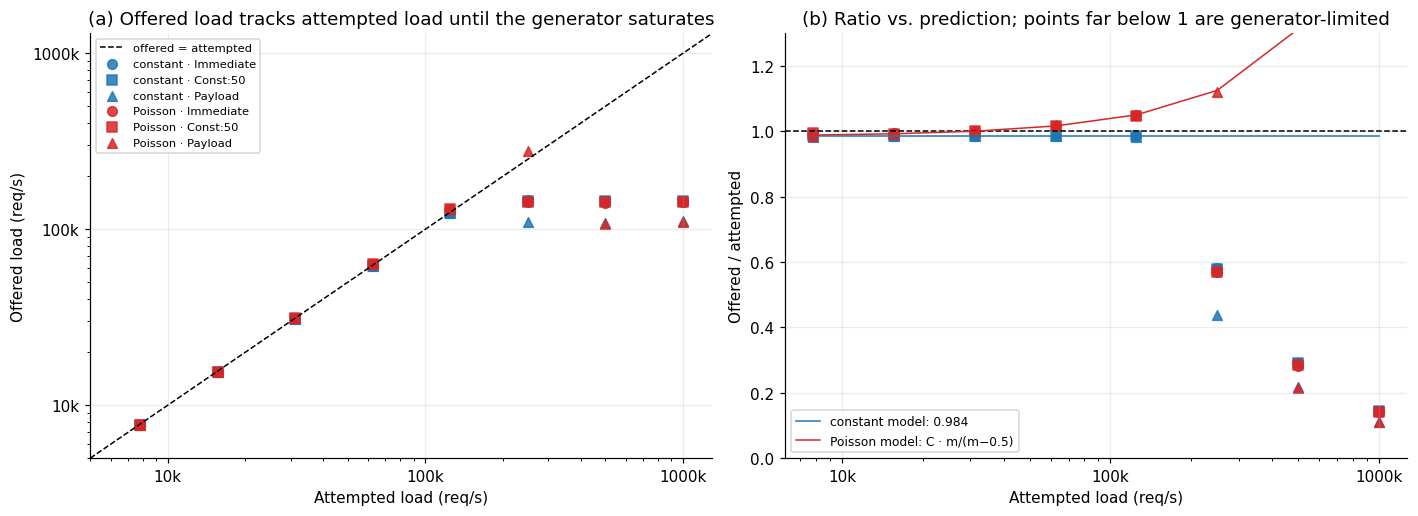

In [ ]:
ol = df[df.strategy != 'closed-loop'].copy()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

a = ax[0]; lim = [5e3, 1.3e6]
a.plot(lim, lim, 'k--', lw=1, label='offered = attempted')
for s in STRATS[1:]:
    for w in WL:
        d = ol[(ol.strategy == s) & (ol.workload == w)]
        a.scatter(d.attempted_rps, d.offered_rps, c=COL[s], marker=MK[w], s=40, alpha=.85, label=f'{LBL[s][10:]} · {w}')
a.set(xscale='log', yscale='log', xlim=lim, ylim=lim, xlabel='Attempted load (req/s)', ylabel='Offered load (req/s)',
      title='(a) Offered load tracks attempted load until the generator saturates')
a.xaxis.set_major_formatter(kfmt); a.yaxis.set_major_formatter(kfmt); a.legend(fontsize=7.5, loc='upper left')

# Quantify the sub-ceiling behaviour: constant shortfall C, plus Poisson truncation bias m/(m-0.5)
ok = ol[ol.interval_us >= 8]
C = (ok[ok.strategy == 'open-loop-constant'].offered_rps / ok[ok.strategy == 'open-loop-constant'].attempted_rps).median()
m = np.array([1, 2, 4, 8, 16, 32, 64, 128])
b = ax[1]
b.axhline(1, color='k', ls='--', lw=1)
b.plot(1e6 / m, np.full(len(m), C), color=COL['open-loop-constant'], lw=1, label=f'constant model: {C:.3f}')
b.plot(1e6 / m, C * m / (m - .5), color=COL['open-loop-poisson'], lw=1, label='Poisson model: C · m/(m−0.5)')
for s in STRATS[1:]:
    for w in WL:
        d = ol[(ol.strategy == s) & (ol.workload == w)]
        b.scatter(d.attempted_rps, d.offered_rps / d.attempted_rps, c=COL[s], marker=MK[w], s=40, alpha=.85)
b.set(xscale='log', ylim=(0, 1.3), xlabel='Attempted load (req/s)', ylabel='Offered / attempted',
      title='(b) Ratio vs. prediction; points far below 1 are generator-limited')
b.xaxis.set_major_formatter(kfmt); b.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

In [ ]:
# Observed vs predicted offered/attempted ratio in the region where the generator is *not* the bottleneck.
rows = []
for s in STRATS[1:]:
    for iv in [128, 64, 32, 16, 8]:
        d = ol[(ol.strategy == s) & (ol.interval_us == iv)]
        pred = C if s == 'open-loop-constant' else C * iv / (iv - .5)
        rows.append({'strategy': LBL[s], 'interval_us': iv, 'observed (mean of 3 workloads)': (d.offered_rps / d.attempted_rps).mean(), 'predicted': pred})
tab = pd.DataFrame(rows); tab['error_%'] = 100 * (tab['observed (mean of 3 workloads)'] / tab.predicted - 1)
print(tab.round(3).to_string(index=False))
print('\nPoisson, Payload, 4µs interval (the one run where the Poisson generator kept up at 250k attempted):',
      round((ol[(ol.strategy=="open-loop-poisson")&(ol.workload=="Payload")&(ol.interval_us==4)].eval("offered_rps/attempted_rps")).iloc[0], 3),
      'vs predicted', round(C * 4 / 3.5, 3))

          strategy  interval_us  observed (mean of 3 workloads)  predicted  error_%
Open-loop constant          128                           0.983      0.984   -0.109
Open-loop constant           64                           0.985      0.984    0.020
Open-loop constant           32                           0.985      0.984    0.003
Open-loop constant           16                           0.985      0.984    0.044
Open-loop constant            8                           0.984      0.984   -0.011
 Open-loop Poisson          128                           0.990      0.988    0.136
 Open-loop Poisson           64                           0.992      0.992    0.017
 Open-loop Poisson           32                           1.001      1.000    0.103
 Open-loop Poisson           16                           1.017      1.016    0.081
 Open-loop Poisson            8                           1.048      1.050   -0.173

Poisson, Payload, 4µs interval (the one run where the Poisson generator kep

**Reading the result.**

* *Constant:* the generator delivers a steady ≈98.5 % of the attempted rate from 7.8k to 125k req/s. Because the ratio does not change with rate, the shortfall looks like a fixed amount of time per run (≈150 ms of the 10 s window), not a per-request cost. I have not isolated the cause.
* *Poisson:* offered/attempted deviates from the constant case in exactly the way the truncation model predicts (largest at short intervals). Truncating an `Exp(mean = m µs)` sample to whole µs shortens the mean gap to ≈ m − 0.5, so offered load is inflated by `m / (m − 0.5)`. The model matches observation to within 0.2 % for every interval from 8 to 128 µs. This confirms the Poisson generator is producing the intended arrival process, and it quantifies a known bias (up to ≈+5 % at an 8 µs mean). **When comparing Poisson to constant, I therefore compare at matched offered load, not matched interval.** A fix is to sample in nanoseconds or round instead of truncating.
* *Generator ceiling:* at intervals of 1, 2 and 4 µs (attempted 250k–1M req/s) offered load collapses to ≈141–146k (Immediate, Const:50) or ≈107–112k (Payload) req/s, regardless of the attempted rate. **These three runs measure the generator's limit, not additional load levels.** The one exception, Poisson/Payload at 4 µs (279k offered), shows the ceiling is not a hard constant: it varies run to run.

### 3.2 Offered vs achieved load
If the server keeps up, achieved = offered. Where it cannot, achieved must fall below offered, and the missing fraction is the backlog.

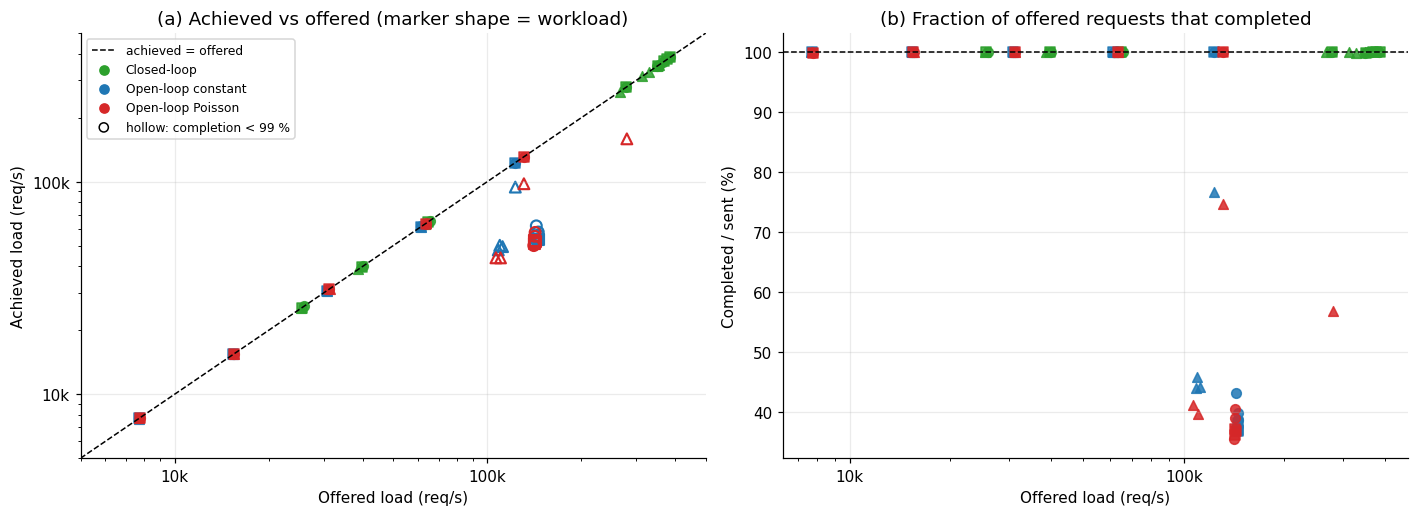

Closed-loop completion %  : min = 99.9969
Open-loop completion % for intervals >= 8 µs (Payload@8 µs excluded, it is already saturated): min = 99.9961


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
a = ax[0]; lim = [5e3, 5e5]
a.plot(lim, lim, 'k--', lw=1, label='achieved = offered')
for s in STRATS:
    for w in WL:
        d = df[(df.strategy == s) & (df.workload == w)]
        ok_, sat = d[~d.saturated], d[d.saturated]
        a.scatter(ok_.offered_rps, ok_.achieved_rps, c=COL[s], marker=MK[w], s=40, alpha=.85)
        a.scatter(sat.offered_rps, sat.achieved_rps, facecolors='none', edgecolors=COL[s], marker=MK[w], s=50, lw=1.4)
for s in STRATS: a.scatter([], [], c=COL[s], label=LBL[s])
a.scatter([], [], facecolors='none', edgecolors='k', label='hollow: completion < 99 %')
a.set(xscale='log', yscale='log', xlim=lim, ylim=lim, xlabel='Offered load (req/s)', ylabel='Achieved load (req/s)',
      title='(a) Achieved vs offered (marker shape = workload)')
a.xaxis.set_major_formatter(kfmt); a.yaxis.set_major_formatter(kfmt); a.legend(fontsize=8)

b = ax[1]
for s in STRATS:
    for w in WL:
        d = df[(df.strategy == s) & (df.workload == w)]
        b.scatter(d.offered_rps, d.completion_pct, c=COL[s], marker=MK[w], s=40, alpha=.85)
b.axhline(100, color='k', ls='--', lw=1)
b.set(xscale='log', xlabel='Offered load (req/s)', ylabel='Completed / sent (%)', title='(b) Fraction of offered requests that completed')
b.xaxis.set_major_formatter(kfmt)
plt.tight_layout(); plt.show()

print('Closed-loop completion %  : min =', round(df[df.strategy=="closed-loop"].completion_pct.min(), 4))
print('Open-loop completion % for intervals >= 8 µs (Payload@8 µs excluded, it is already saturated): min =',
      round(ol[(ol.interval_us >= 8) & ~((ol.workload=="Payload") & (ol.interval_us==8))].completion_pct.min(), 4))

Below the knee, offered and achieved agree to within 0.004 %; the closed-loop curve lies on the diagonal by construction, because a closed-loop client cannot send a request it has not yet been allowed to send. For open loop the diagonal holds up to ≈123k (constant) / ≈131k (Poisson) req/s and then **breaks sharply**: the saturated runs (offered ≈140–146k) complete only 36–46 % of what they send (Poisson/Payload at 4 µs: 57 %). The server does not merely plateau; achieved load *falls* (from ≈131k to ≈44–62k req/s) when offered load rises by only ≈10 %. §7 discusses why.

### 3.3 Closed loop: Little's law as a consistency check
In a closed system with `N` always-busy threads, mean latency must equal `N / X` (X = achieved throughput). I only have percentiles, so the check is that `N / X` falls between p50 and p99.

In [ ]:
cl = df[df.strategy == 'closed-loop'].copy()
cl['little_N_over_X_us'] = cl.threads / cl.achieved_rps * 1e6
cl['between_p50_p99'] = (cl.little_N_over_X_us >= cl.p50_us) & (cl.little_N_over_X_us <= cl.p99_us)
print(cl[cl.workload == 'Immediate'][['threads', 'achieved_rps', 'little_N_over_X_us', 'p50_us', 'p95_us', 'p99_us', 'between_p50_p99']]
      .round(1).to_string(index=False))
print(f'\nN/X lies between p50 and p99 in {cl.between_p50_p99.sum()} of {len(cl)} closed-loop runs (all workloads)')
print(cl[~cl.between_p50_p99][['workload', 'threads', 'little_N_over_X_us', 'p50_us', 'p99_us']].round(1).to_string(index=False))

 threads  achieved_rps  little_N_over_X_us  p50_us  p95_us  p99_us  between_p50_p99
     1.0       25978.0                38.5      29      37      41             True
     2.0       40098.9                49.9      39      42      52             True
     4.0       65531.7                61.0      39      88     116             True
     8.0      277822.0                28.8      13      58      75             True
    16.0      384996.2                41.6      27      72     118             True
    32.0      366334.4                87.4      54     135     208             True
    64.0      354884.1               180.3     106     292     505             True
   128.0      349749.3               366.0     215     611    1136             True

N/X lies between p50 and p99 in 23 of 24 closed-loop runs (all workloads)
workload  threads  little_N_over_X_us  p50_us  p99_us
Const:50      2.0                50.3      39      49


The check holds in 23 of 24 runs, and the single miss is within ≈1.3 µs of p99. Closed-loop latency is therefore *determined by* concurrency and throughput, which is the key reason it cannot show overload: when the server slows down, the clients slow down with it.

### 3.4 (Optional) Inter-arrival distribution from raw records
The strongest direct evidence that the generators emit the *intended arrival process* is the distribution of gaps between `send_timestamp`s: a spike at the interval for constant, and an exponential for Poisson (coefficient of variation ≈ 1). This needs a per-run `latency.csv`; point the paths below at any two un-saturated runs (e.g. interval 64 µs) to produce the figure.

In [ ]:
RAW = {'open-loop-constant': None,   # e.g. 'results/open-loop-constant_Immediate_64/latency.csv'
       'open-loop-poisson':  None}   # e.g. 'results/open-loop-poisson_Immediate_64/latency.csv'
INTERVAL_US = 64

if all(RAW.values()):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for s, path in RAW.items():
        gaps = np.diff(np.sort(pd.read_csv(path).send_timestamp.values)).astype(float)    # µs between sends
        print(f'{s}: mean gap = {gaps.mean():.1f} µs (target {INTERVAL_US}), CV = {gaps.std()/gaps.mean():.2f}')
        ax[0].hist(gaps[gaps < 6 * INTERVAL_US], bins=80, alpha=.6, color=COL[s], label=LBL[s], density=True)
        x = np.sort(gaps); ax[1].plot(x, np.arange(1, len(x) + 1) / len(x), color=COL[s], label=LBL[s])
    xs = np.linspace(0, 6 * INTERVAL_US, 200); ax[1].plot(xs, 1 - np.exp(-xs / INTERVAL_US), 'k--', lw=1, label='Exp(mean = interval)')
    ax[0].set(xlabel='gap between sends (µs)', ylabel='density', title='Inter-send gap histogram'); ax[0].legend()
    ax[1].set(xlim=(0, 6 * INTERVAL_US), xlabel='gap (µs)', ylabel='CDF', title='Inter-send gap CDF'); ax[1].legend()
    plt.tight_layout(); plt.show()
else:
    print('Skipped: set RAW paths to per-run latency.csv files to enable this check.')

Skipped: set RAW paths to per-run latency.csv files to enable this check.


## 4. Throughput-latency results

Each panel plots p50, p95 and p99 latency against **offered** throughput. Latency is in **milliseconds** on a log axis with plain-number labels (0.1 ms = 100 µs, 1 ms = 1,000 µs, 1,000 ms = 1 s). I chose milliseconds because the data spans 13 µs to about 8 s, and ms keeps every label short and readable. Throughput ticks are denser than before so points can be read off directly. with one row per generation strategy and one column per workload. Points are joined in order of increasing *attempted* load (more threads, or shorter interval), so the line traces what happens as pressure grows. **Hollow markers = saturated runs** (< 99 % of sent requests completed). Each row has its own y-axis. On a linear axis, as in my first draft of these plots, the open-loop curves are a flat line at zero followed by a vertical wall, and the closed-loop curve is drawn in sorted-throughput order, which wrongly suggests latency *falls* at the highest load.

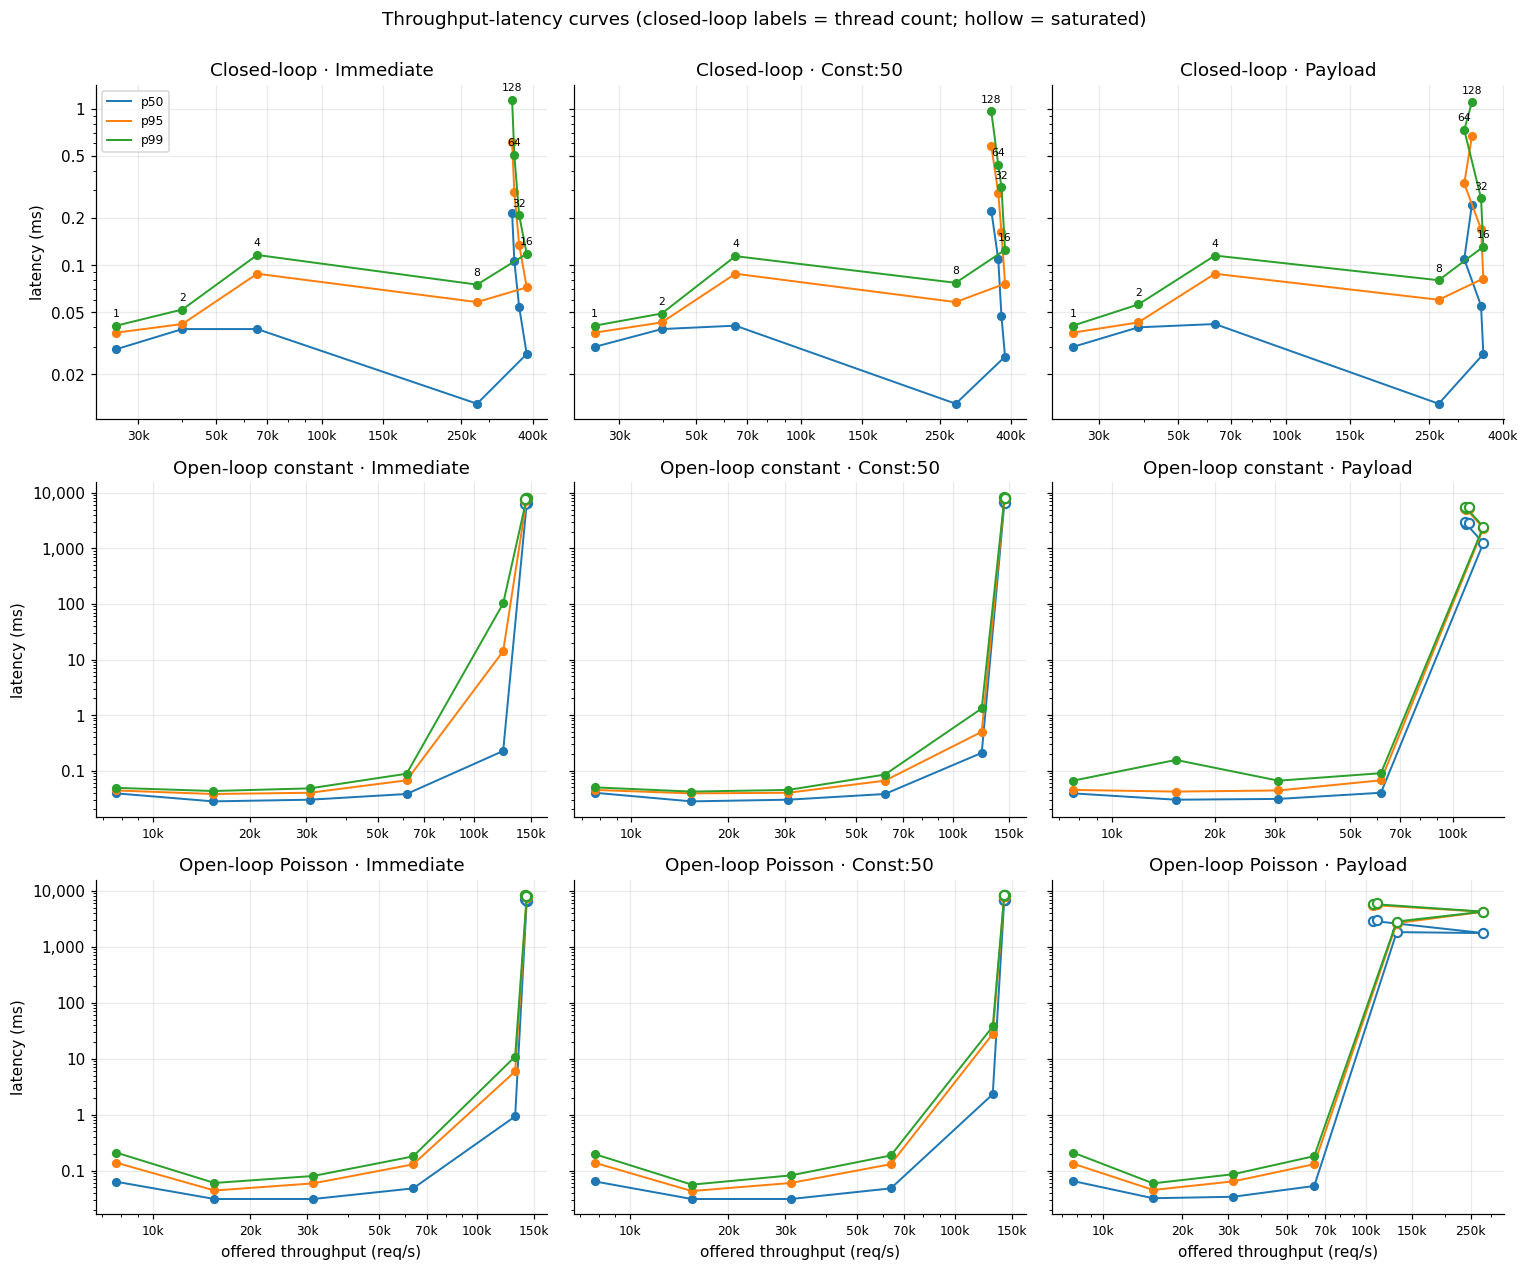

In [ ]:
PC = {'p50': 'tab:blue', 'p95': 'tab:orange', 'p99': 'tab:green'}
fig, axes = plt.subplots(3, 3, figsize=(14, 11.5), sharey='row')
for i, s in enumerate(STRATS):
    for j, w in enumerate(WL):
        a = axes[i, j]; d = ordered(s, w); sat = d.saturated.values
        for p in ('p50', 'p95', 'p99'):
            y = d[p + '_ms'].values; x = d.offered_rps.values
            a.plot(x, y, '-', color=PC[p], lw=1.3, label=p)
            a.plot(x[~sat], y[~sat], 'o', color=PC[p], ms=5)
            a.plot(x[sat], y[sat], 'o', mfc='white', color=PC[p], ms=6, mew=1.4)
        if s == 'closed-loop':
            for x, y, n in zip(d.offered_rps, d.p99_ms, d.threads): a.annotate(f'{int(n)}', (x, y), textcoords='offset points', xytext=(0, 6), fontsize=7, ha='center')
        a.set(xscale='log', yscale='log', title=f'{LBL[s]} · {w}')
        tp_axis(a); lat_axis(a, fine=(s == 'closed-loop'))
        if j == 0: a.set_ylabel('latency (ms)')
        if i == 2: a.set_xlabel('offered throughput (req/s)')
        if i == 0 and j == 0: a.legend(fontsize=8)
fig.suptitle('Throughput-latency curves (closed-loop labels = thread count; hollow = saturated)', y=1.0)
plt.tight_layout(); plt.show()

**What the curves show.**

* **Closed loop** (top row): latency stays between ≈13 µs (p50) and ≈1.1 ms (p99) even at 128 threads. Throughput rises with concurrency, peaks at **16 threads (≈385k req/s for Immediate)**, then *declines* (≈350k at 128 threads) while latency keeps growing: the signature of contention from oversubscribed client and server threads. There is a large jump between 4 and 8 threads (65k → 278k req/s, with p50 *dropping* from 39 to 13 µs) that appears identically in all three workloads, so it is not a plotting artefact. I have not diagnosed it; scheduler wake-up and CPU idle-state effects at low concurrency are plausible candidates.
* **Open loop** (middle and bottom rows): latency is flat at tens of µs up to ≈60k req/s, starts to climb at ≈123–131k, and then jumps to **seconds** (p50 6–7 s, p99 7.7–8.4 s for Immediate) in the saturated runs. Between the last good point and the first saturated one, p99 grows by about five orders of magnitude (≈88 µs → ≈8 s).
* **Percentile spread:** p50, p95 and p99 are nearly identical at saturation (the queue is long and FIFO, so every request waits roughly the same), but they fan out sharply in the pre-saturation knee (e.g. constant/Immediate at 123k offered: p50 226 µs, p95 14 ms, p99 102 ms), exactly where queues are building and draining.

The same data against **achieved** throughput (the conventional x-axis) shows the open-loop curve turning back on itself at saturation, which is why I use offered load as the primary axis: achieved load *falls* while latency explodes.

## 5. Request-generation strategies compared

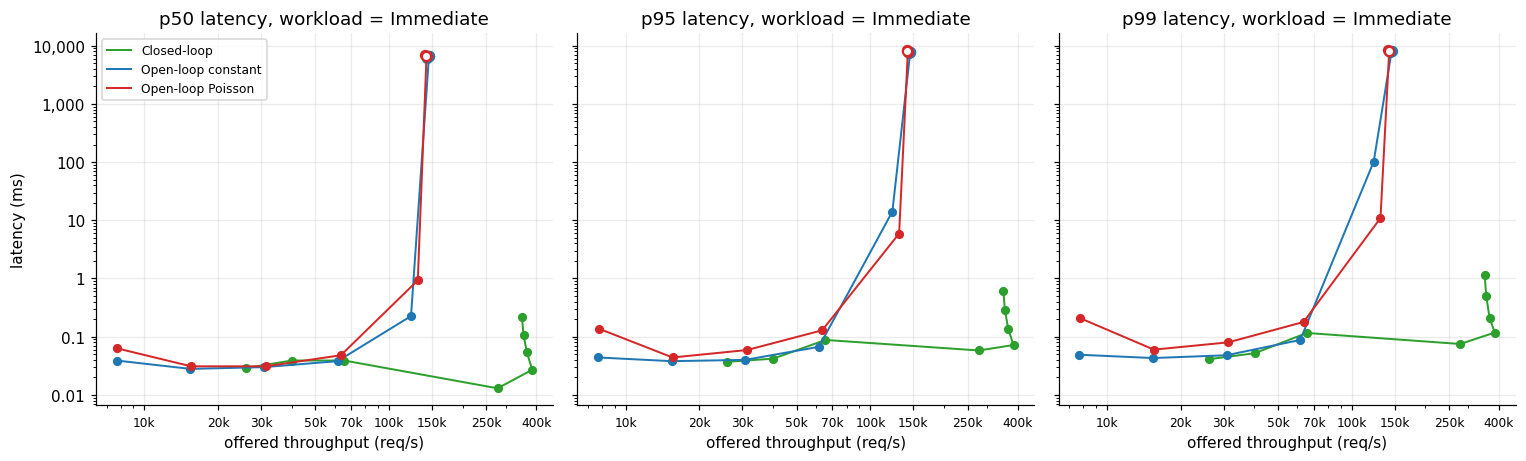

In [ ]:
w = 'Immediate'
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), sharey=True)
for a, p in zip(axes, ('p50', 'p95', 'p99')):
    for s in STRATS:
        d = ordered(s, w); sat = d.saturated.values; x, y = d.offered_rps.values, d[p + '_ms'].values
        a.plot(x, y, '-', color=COL[s], lw=1.3, label=LBL[s])
        a.plot(x[~sat], y[~sat], 'o', color=COL[s], ms=5); a.plot(x[sat], y[sat], 'o', mfc='white', color=COL[s], ms=6, mew=1.4)
    a.set(xscale='log', yscale='log', xlabel='offered throughput (req/s)', title=f'{p} latency, workload = {w}')
    tp_axis(a); lat_axis(a)
axes[0].set_ylabel('latency (ms)'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# Matched-load comparison of the two open-loop generators, below saturation.
piv = ol.pivot_table(index=['workload', 'interval_us'], columns='strategy', values=['p50_us', 'p95_us', 'p99_us', 'offered_rps'])
cmp = pd.DataFrame({f'{p} ratio': piv[p + '_us']['open-loop-poisson'] / piv[p + '_us']['open-loop-constant'] for p in ('p50', 'p95', 'p99')})
cmp['offered ratio'] = piv['offered_rps']['open-loop-poisson'] / piv['offered_rps']['open-loop-constant']
cmp = cmp.reset_index(); cmp = cmp[cmp.interval_us.isin([16, 32, 64, 128])].sort_values(['workload', 'interval_us'], ascending=[True, False])
print('Poisson / constant latency ratios at the same interval (offered ratio shows the load mismatch from truncation):')
print(cmp.round(2).to_string(index=False))

Poisson / constant latency ratios at the same interval (offered ratio shows the load mismatch from truncation):
 workload  interval_us  p50 ratio  p95 ratio  p99 ratio  offered ratio
 Const:50        128.0       1.60       3.07       3.94           1.01
 Const:50         64.0       1.11       1.10       1.33           1.01
 Const:50         32.0       1.03       1.50       1.82           1.02
 Const:50         16.0       1.26       1.97       2.19           1.03
Immediate        128.0       1.62       3.14       4.27           1.01
Immediate         64.0       1.11       1.16       1.40           1.01
Immediate         32.0       1.03       1.48       1.67           1.02
Immediate         16.0       1.26       1.93       2.03           1.03
  Payload        128.0       1.67       2.96       3.18           1.00
  Payload         64.0       1.07       1.07       0.38           1.01
  Payload         32.0       1.10       1.45       1.30           1.02
  Payload         16.0       1.32   

**Closed loop vs open loop.** Closed loop never lets more than `N` requests be outstanding, so latency can grow only as `N / X` (§3.3). At 128 threads it pushes ≈350k req/s with p99 ≈ 1.1 ms. Open loop keeps sending on schedule whether or not the server is keeping up, so when offered load exceeds capacity the queue grows without bound and latency is limited only by the run length. The closed-loop curve therefore *cannot* reveal a saturation point as a latency explosion; it can only reveal where throughput stops growing (here ≈16 threads). It also cannot separate offered from achieved load (§3.2), whereas open loop can.

**Constant vs Poisson.** At the same mean rate, Poisson arrivals are bursty: some gaps are far shorter than the mean, so requests momentarily queue even when average utilisation is low. Below saturation, with offered load matched to within 1–3 %, Poisson p95 is **1.1–3.1×** the constant-rate p95 for Immediate and Const:50 at every interval from 16 to 128 µs (p99 is 1.3–4.3×); the Payload comparison is noisier (one run's p99 is an outlier, so its p99 ratio is 0.38 at the 64 µs interval). Medians differ less (e.g. 30 vs 31 µs at 32 µs; 28 vs 31 µs at 64 µs; 38 vs 48 µs at 16 µs). The effect is largest at the *lowest* load (128 µs: p50 39 vs 63 µs). Queueing alone does not explain that, since utilisation there is only ≈6 % (7.7k of ≈131k req/s), so I suspect timer and wake-up jitter in the sender instead, but I have not tested this.

Near the knee (8 µs interval) the Poisson generator has the worse median in both workloads where both reached it (Immediate: 930 vs 226 µs; Const:50: 2.3 ms vs 209 µs), but it also offers 6–7 % more load there (§3.1), and the tails disagree between workloads (Immediate: constant p99 is *worse*). With one trial per configuration I do not claim a strategy ordering inside the knee.

## 6. Workload comparison: Immediate vs Const:50 vs Payload

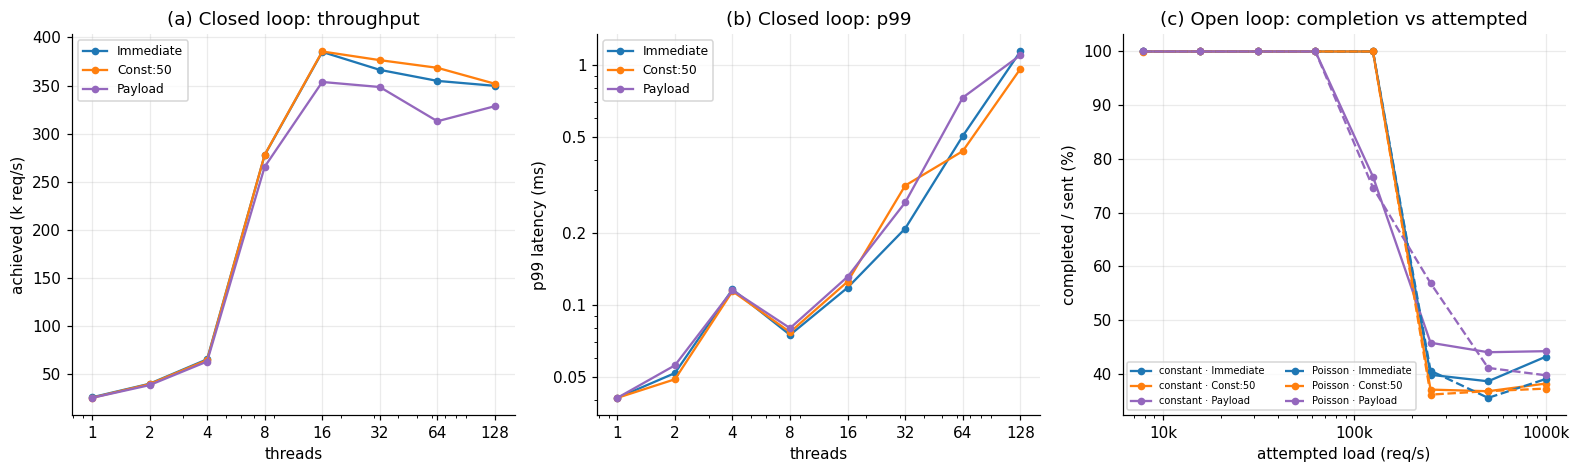

Closed-loop throughput relative to Immediate (%):
workload  Const:50  Payload
threads                    
1.0           -1.9     -2.1
2.0           -0.9     -3.6
4.0           -1.2     -3.5
8.0            0.1     -4.4
16.0           0.1     -8.1
32.0           2.8     -4.9
64.0           3.8    -11.8
128.0          0.6     -6.0


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))
WC = {'Immediate': 'tab:blue', 'Const:50': 'tab:orange', 'Payload': 'tab:purple'}
for w in WL:
    d = ordered('closed-loop', w)
    ax[0].plot(d.threads, d.achieved_rps / 1000, '-o', color=WC[w], label=w, ms=4)
    ax[1].plot(d.threads, d.p99_ms, '-o', color=WC[w], label=w, ms=4)
ax[0].set(xscale='log', xticks=[1, 2, 4, 8, 16, 32, 64, 128], xlabel='threads', ylabel='achieved (k req/s)', title='(a) Closed loop: throughput')
ax[1].set(xscale='log', yscale='log', xticks=[1, 2, 4, 8, 16, 32, 64, 128], xlabel='threads', ylabel='p99 latency (ms)', title='(b) Closed loop: p99')
lat_axis(ax[1], fine=True)
for a in ax[:2]: a.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}')); a.legend(fontsize=8)
for s, ls in (('open-loop-constant', '-'), ('open-loop-poisson', '--')):
    for w in WL:
        d = ordered(s, w)
        ax[2].plot(d.attempted_rps, d.completion_pct, ls, color=WC[w], marker='o', ms=4, label=f'{LBL[s][10:]} · {w}')
ax[2].set(xscale='log', xlabel='attempted load (req/s)', ylabel='completed / sent (%)', title='(c) Open loop: completion vs attempted')
ax[2].xaxis.set_major_formatter(kfmt); ax[2].legend(fontsize=6.5, ncol=2)
plt.tight_layout(); plt.show()

cl_i = df[(df.strategy == 'closed-loop')].pivot_table(index='threads', columns='workload', values='achieved_rps')
print('Closed-loop throughput relative to Immediate (%):')
print((100 * (cl_i.div(cl_i['Immediate'], axis=0) - 1))[['Const:50', 'Payload']].round(1).to_string())

* **Const:50 is indistinguishable from Immediate.** Closed-loop throughput is within 4 % everywhere and open-loop saturation behaves the same. Its per-request work is therefore negligible next to the ≈30–40 µs round-trip floor (the results file does not record the unit of the `50`, so I am inferring this from the data alone; if it is nanoseconds or a few microseconds, this is expected).
* **Payload is measurably more expensive.** Closed-loop throughput is 5–12 % lower than Immediate at ≥16 threads, and p99 at 64 threads is ≈1.45× higher (730 vs 505 µs), but it is within 5 % at ≤ 8 threads. In open loop, Payload saturates **earlier**: at the 125k req/s attempted rate Immediate and Const:50 complete 100 % but Payload completes ≈75–77 %. Its generator ceiling is also lower (≈110k vs ≈145k offered at 1–2 µs intervals), consistent with the sender and reader contending for CPU while handling larger responses (untested).
* In every workload, the *shape* is the same (flat, knee, collapse); the workload shifts where the knee falls, not what it looks like.

## 7. Saturation analysis

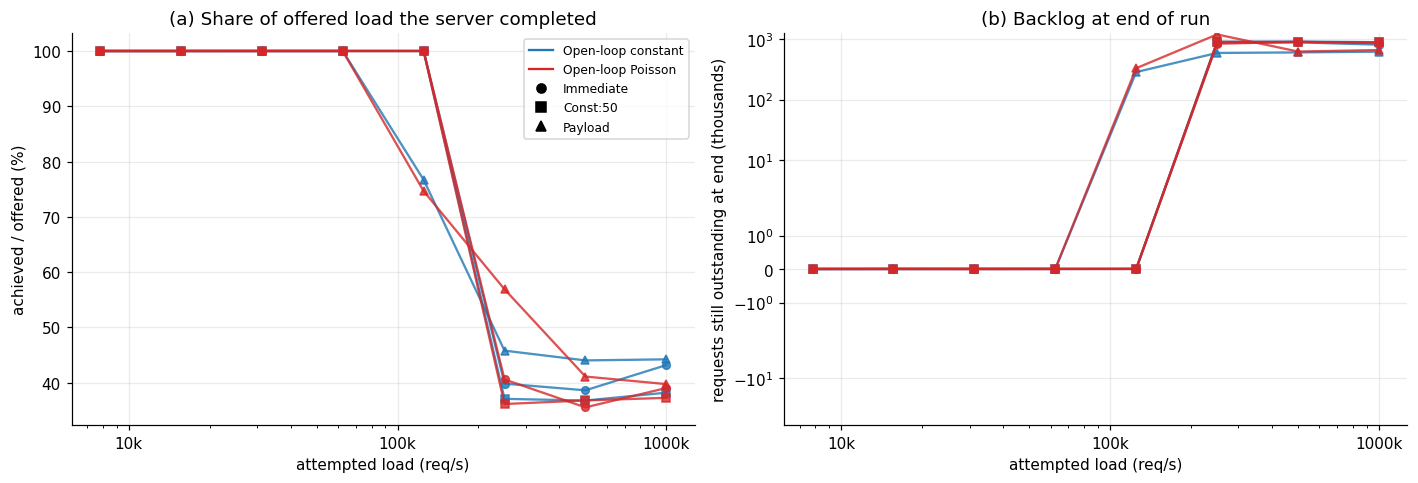

          strategy  workload  interval_us  attempted_rps  offered_rps  achieved_rps  completion_pct  backlog_k  p50_s  p99_s  p99/runtime
open-loop-constant  Const:50          1.0      1000000.0     145127.2       55401.3           38.17     897.26   6.68   8.13         0.81
open-loop-constant  Const:50          2.0       500000.0     145515.6       53470.8           36.75     920.45   6.81   8.18         0.82
open-loop-constant  Const:50          4.0       250000.0     144938.7       53702.8           37.05     912.36   6.82   8.24         0.82
open-loop-constant Immediate          1.0      1000000.0     143579.3       61975.8           43.16     816.04   6.17   7.70         0.77
open-loop-constant Immediate          2.0       500000.0     145305.1       56082.7           38.60     892.22   6.61   8.04         0.80
open-loop-constant Immediate          4.0       250000.0     145654.7       57981.3           39.81     876.73   6.55   8.03         0.80
open-loop-constant   Payload      

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for s in STRATS[1:]:
    for w in WL:
        d = ordered(s, w)
        ax[0].plot(d.attempted_rps, d.achieved_rps / d.offered_rps * 100, '-', marker=MK[w], color=COL[s], alpha=.8, ms=5)
        ax[1].plot(d.attempted_rps, d.backlog / 1000, '-', marker=MK[w], color=COL[s], alpha=.8, ms=5)
for s in STRATS[1:]: ax[0].plot([], [], color=COL[s], label=LBL[s])
for w in WL: ax[0].plot([], [], 'k', marker=MK[w], ls='', label=w)
ax[0].set(xscale='log', xlabel='attempted load (req/s)', ylabel='achieved / offered (%)', title='(a) Share of offered load the server completed'); ax[0].legend(fontsize=8)
ax[1].set(xscale='log', yscale='symlog', xlabel='attempted load (req/s)', ylabel='requests still outstanding at end (thousands)', title='(b) Backlog at end of run')
for a in ax: a.xaxis.set_major_formatter(kfmt)
plt.tight_layout(); plt.show()

sat = df[df.saturated & (df.strategy != 'closed-loop')].copy()
sat['p50_s'] = sat.p50_us / 1e6; sat['p99_s'] = sat.p99_us / 1e6; sat['p99/runtime'] = sat.p99_s / RUNTIME; sat['backlog_k'] = sat.backlog / 1000
print(sat[['strategy', 'workload', 'interval_us', 'attempted_rps', 'offered_rps', 'achieved_rps', 'completion_pct', 'backlog_k', 'p50_s', 'p99_s', 'p99/runtime']]
      .round(2).to_string(index=False))

**Where saturation begins.** For a single connection the sustainable rate is about **123k req/s (constant) to 131k req/s (Poisson)**, since every Immediate and Const:50 run up to those loads completes ≈100 % of its requests (Payload begins to fall behind one step earlier, at 125k attempted). The first sign is not throughput but the latency tail: at ≈123–131k offered, p95 and p99 are already ≈50–1,200× their values at ≈62k (Immediate p99: 88 µs → 102 ms constant, 179 µs → 10.9 ms Poisson), while throughput still equals offered load. The next step, ≈143k offered, is past the cliff.

**What happens past capacity.** Open-loop sending continues regardless of responses, so the excess accumulates as backlog (≈0.3–1.2 million requests outstanding at the end of the saturated runs). Two features of the results need care:

1. **Latency in saturated runs is bounded by the run length, not by the system.** Latency is only recorded for *completed* requests, which are only 36–46 % of what was sent in the 1–4 µs runs (up to 57 % for Payload). The ≈8 s p99 is a lower bound on what the un-completed majority experienced; saturated p99s are best read as "about the whole run" (see the `p99/runtime` column), and the **completion %** and **backlog** are the more honest saturation measures.
2. **Achieved throughput falls instead of plateauing.** At ≈131k offered the server completes everything; at ≈143k it completes ≈55k req/s. A plain overloaded FIFO server should hold near its capacity (≈131k+), not lose >50 % of it. Plausible causes, none of which I have separated with the current data: (i) once socket buffers fill, `write_all` blocks and the "open-loop" sender is back-pressured; (ii) when the sender is behind schedule `sleep` returns immediately, so it turns into a busy loop that steals CPU from the reader and server threads (especially if client and server share a machine); (iii) the unbounded timestamp channel and the per-request memory growth. Also, a steady 55k req/s service rate would predict a median latency near 3 s for completed requests, but I observe 6–7 s, which suggests completions are concentrated late in the run. A per-second completion timeline from a raw `latency.csv` would settle this, and pinning client and server to separate cores (or hosts) would test (ii).

**Closed loop does not saturate in this sense.** Its analogue is the throughput peak at 16 threads followed by a mild decline, with latency growing only in proportion to the thread count.

## 8. Conclusion

* **Generators behave as designed.** Constant open loop offers a steady ≈98.5 % of the attempted rate; Poisson offered load matches a simple truncation model within 0.2 %; closed-loop latencies satisfy Little's law in 23 of 24 runs (the miss is within ≈1.3 µs of p99). Raw inter-arrival histograms (§3.4) would complete this evidence.
* **Attempted, offered and achieved load are three distinct quantities.** They coincide at low load, split at the generator ceiling (offered < attempted: attempted 250k–1M → offered ≈110–146k) and again at server saturation (achieved < offered: ≈40 % completion).
* **Throughput and latency relate as queueing theory predicts only in open loop.** Latency is flat, then explodes once offered load passes capacity; closed loop trades that signal for a self-limiting load and a latency bounded by `N / X`.
* **Arrival process matters.** At matched offered load, Poisson arrivals give a worse p95/p99 than constant-rate arrivals, so constant-rate tests understate tail latency for bursty real traffic.
* **Workloads shift the knee, not the shape.** Const:50 ≈ Immediate; Payload costs 5–12 % throughput in closed loop and saturates earlier in open loop.

### Limitations and threats to validity
* **One trial per configuration.** There are no error bars; near the knee the results are noisy (e.g. the Poisson/Payload run at 4 µs offered 279k while the neighbouring runs offered ≈110–146k). Repeating each point at least three times is the improvement I would make first.
* **Closed and open loop are not tested at equal server concurrency.** Closed loop uses `N` connections (and `N` server threads); open loop uses one connection and a serial server thread. Their *maximum* throughputs (385k vs ≈131k) therefore reflect connection-level parallelism as well as the generation strategy; the strategy comparison is cleanest at low load.
* **Latency is measured from the actual send time, not the scheduled send time.** If the sender runs late, that lateness is not in the latency number (it shows up as lower offered load instead), which understates tail latency in the generator-limited regime.
* **Only completed requests are recorded**, so saturated latency percentiles are biased low (§7).
* **Poisson truncation bias** (up to ≈+5 % at 8 µs) and the ≈1.5 % constant-rate shortfall are documented but not corrected in the data above.